In [1]:
import cv2
import time
import random
from random import sample

from matplotlib import pyplot as plt
import math
import os
import numpy as np

import mediapipe as mp
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Conv3D, LSTM, Dense, Dropout, Bidirectional, MaxPool3D, Activation, Reshape, SpatialDropout3D, BatchNormalization, TimeDistributed, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler


2025-03-26 17:21:18.760635: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743009678.781931 1026213 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743009678.788178 1026213 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1743009678.805565 1026213 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1743009678.805590 1026213 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1743009678.805593 1026213 computation_placer.cc:177] computation placer alr

In [2]:
align_file_test = "/media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S1/align/bbaf2s.align" 


def ParseAlign(align_file: str)-> list[bool, int, int]:
    """
    Provides Clip information for a single .align file
    Args:
        align_file: path to align file
    Returns:
        clip_alignments: [[sil,start_frame,end_frame],[sil,start_frame end_frame],[talking,start_frame,end_frame],[talking,start_frame,end_frame]]
    """

    with open(align_file, 'r') as file:
        clip_alignment = []
        start_talk=0
        end_talk=0
        for line in file:
            alignment = line.strip('\n').split(" ")
            start, end, word = alignment
            if word == "sil":
                start_frame = math.ceil(int(start)*0.001)
                end_frame = math.ceil(int(end)*0.001)
                clip_alignment.append(["sil", start_frame, end_frame])
                
            else:
                if start_talk == 0:
                    start_talk = math.ceil(int(start)*0.001)
                if math.ceil(int(end)*0.001) > end_talk:
                    end_talk = math.ceil(int(end)*0.001)
        midpoint = math.ceil(start_talk + (end_talk-start_talk)/2)
        clip_alignment.append(["talking", start_talk, midpoint])
        clip_alignment.append(["talking", midpoint, end_talk])
            

    return clip_alignment

ParseAlign(align_file=align_file_test)

[['sil', 0, 13], ['sil', 51, 75], ['talking', 13, 32], ['talking', 32, 51]]

In [3]:
FULL_GRID_DIR = "/media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata"

def ParseDataset(path: str) -> list[bool, int, int, str]:
    """Given a formatted dataset, returns all clip infromation
    Args:
        path: path to dataset
    Returns:
        clip_alignments: [istalking: bool,start_frame:int,end_frame:int, videopath:str]"""

    dataset_abstracted = []
    for subject in os.listdir(path):
        try:
            align_folder = path + "/" + subject + "/align"
            video_folder = path + "/" + subject + "/" + subject
            for filename in os.listdir(align_folder):
                video_clip_name = filename.split(".")[0]+".mpg"
                video_path = video_folder + "/"+ video_clip_name
                alignments = ParseAlign(align_folder+"/"+filename)
                if os.path.isfile(video_path): #Try video path except skip
                    for alignment in alignments:
                        clip_values = [*alignment, video_path]
                        dataset_abstracted.append(clip_values)

        except Exception as e:
            print("Exception Error:", e)

    return dataset_abstracted

dataset_values = ParseDataset(FULL_GRID_DIR)
print(dataset_values[0])



['sil', 0, 14, '/media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S4/S4/bbae9n.mpg']


In [4]:
MOUTH_LANDMARKS = [0, 267, 269, 270, 409, 306, 375, 321, 405, 314, 17, 84, 181, 91, 146, 61, 185, 40, 39,
                                37]

mpDraw = mp.solutions.drawing_utils
mpFaceMesh = mp.solutions.face_mesh
faceMesh = mpFaceMesh.FaceMesh(max_num_faces=2)
drawSpec = mpDraw.DrawingSpec(thickness=1, circle_radius=1)

def FindMouth(img, output_format):
    landmarks = []
    try:
        results = faceMesh.process(img)
        if results.multi_face_landmarks:
            for faceLms in results.multi_face_landmarks:
                # mpDraw.draw_landmarks(img, faceLms, mpFaceMesh.FACEMESH_CONTOURS, drawSpec, drawSpec)
                for id,lm in enumerate(faceLms.landmark):
                    image_height, image_width, image_channels = img.shape
                    x,y = int(lm.x*image_width), int(lm.y*image_height)
                    if output_format == "mouthrgb":
                        if id == 0:
                            return img[y-40:y+60,x-50:x+50,:]
                    if output_format == "liplandmarks":
                        if id in MOUTH_LANDMARKS:
                            landmarks.append((x,y))
            if landmarks:
                return landmarks
    except Exception as e:
        print("Failed to FindMouth:", e)
    return img
        

I0000 00:00:1743009683.343193 1026213 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1743009683.445584 1027177 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 550.120), renderer: NVIDIA GeForce RTX 4070/PCIe/SSE2


In [5]:
# frameformats -> mouthrgb, mouthgreyscale, liplandmarks, fullframe/face



class FrameGenerator():
    """Given an array of dataset values, returns labeled and formatted data/frames"""
    def __init__(self, dataset_values, training=False, frame_format="mouthrgb"):
        self.dataset_values = dataset_values
        self.training = training
        self.frame_format = frame_format
        
        match self.frame_format:
            case "mouthrgb":
                self.input_shape = (10, 100, 100, 1)
            case "liplandmarks":
                self.input_shape = (10, 2, 20)
                


    def __call__(self):
        if self.training:
            np.random.shuffle(self.dataset_values) #Use a different shuffle method?
            # print((self.dataset_values[0]))

        # print("Test dataset format" ,self.dataset_values)
        for isTalking, start_frame, end_frame, video_path in self.dataset_values:
            label = np.int16(0 if isTalking == "sil" else 1) 
            formatted_frames = []

            cap = cv2.VideoCapture(video_path)
            count = 0
            while count < self.input_shape[0]:
                cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame+count)
                ret, frame = cap.read()
                if not ret:
                    print("failed to read: " + video_path + str(count))
                    # time.sleep(1)
                    formatted_frames.append(np.zeros((self.input_shape[1],self.input_shape[2], 1), dtype=np.float32))
                else:
                    frame = FindMouth(frame, self.frame_format)
                    if self.frame_format == "mouthrgb":
                        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                        # print(frame.shape)
                        frame = tf.expand_dims(frame, axis=-1)
                        frame = tf.image.resize_with_pad(frame,self.input_shape[1],self.input_shape[2]) 
                        frame = tf.image.convert_image_dtype(frame, tf.float32)
                    if self.frame_format == "liplandmarks":
                        pass
                    formatted_frames.append(frame)
                count += 1

            cap.release()

            while len(formatted_frames) < 10:
                formatted_frames.append(np.zeros((self.input_shape[1], self.input_shape[2], 1), dtype=np.float32))

            formatted_frames = np.array(formatted_frames, dtype=np.float32)
            # print(formatted_frames)
            if self.frame_format == "mouthrgb":
                formatted_frames = np.array(formatted_frames)
            yield formatted_frames, label

    




print(len(dataset_values))
train_dataset_values = sample(dataset_values, 8000)
val_dataset_values = sample(dataset_values, 2000)
print(len(train_dataset_values), len(val_dataset_values))                    

fg = FrameGenerator(dataset_values, True)

first_item, label = next(fg())

print(first_item.shape, label)
# print(label)        

120000
8000 2000


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


W0000 00:00:1743009683.454160 1027173 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1743009683.465756 1027166 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1743009683.561064 1027168 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
I0000 00:00:1743009683.759381 1026213 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5729 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070, pci bus id: 0000:01:00.0, compute capability: 8.9


(10, 100, 100, 1) 1


In [6]:
# train_ds = train_ds.batch(2)
# val_ds = val_ds.batch(2)

input_shape = (10, 100, 100, 1)

output_signature = (tf.TensorSpec(shape = input_shape, dtype = tf.float32, name="frames"),
                    tf.TensorSpec(shape = (), dtype = tf.int16, name="labels"))
train_ds = tf.data.Dataset.from_generator(FrameGenerator(train_dataset_values, True),
                                          output_signature = output_signature)
val_ds = tf.data.Dataset.from_generator(FrameGenerator(val_dataset_values, True),
                                          output_signature = output_signature)

print(train_ds)


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).cache().prefetch(buffer_size = AUTOTUNE)
print(train_ds)
val_ds = val_ds.shuffle(1000).cache().prefetch(buffer_size = AUTOTUNE)

<_FlatMapDataset element_spec=(TensorSpec(shape=(10, 100, 100, 1), dtype=tf.float32, name='frames'), TensorSpec(shape=(), dtype=tf.int16, name='labels'))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(10, 100, 100, 1), dtype=tf.float32, name='frames'), TensorSpec(shape=(), dtype=tf.int16, name='labels'))>


In [7]:
train_ds = train_ds.batch(2)
val_ds = val_ds.batch(2)

# print("Frames shape:", frames.shape)  # Should be (10, 100, 100, 3)
# print("Labels:", labels)  # Should be a single int16 label
for i in range(10):
    print(train_ds.take(i))

<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 100, 100, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int16, name=None))>
<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 100, 100, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int16, name=None))>
<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 100, 100, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int16, name=None))>
<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 100, 100, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int16, name=None))>
<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 100, 100, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int16, name=None))>
<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 100, 100, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int16, name=None))>
<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 100, 100, 1), 

In [8]:



model = models.Sequential([

    layers.Input(shape=input_shape),
    # Input Layer
    # (2+1)D Conv Block 1
    layers.Conv3D(32, kernel_size=(1, 3, 3), padding='same', activation='relu'),
    layers.Conv3D(32, kernel_size=(3, 1, 1), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling3D(pool_size=(1, 2, 2)),

    # (2+1)D Conv Block 2
    layers.Conv3D(64, kernel_size=(1, 3, 3), padding='same', activation='relu'),
    layers.Conv3D(64, kernel_size=(3, 1, 1), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling3D(pool_size=(2, 2, 2)),

    # (2+1)D Conv Block 3
    layers.Conv3D(128, kernel_size=(1, 3, 3), padding='same', activation='relu'),
    layers.Conv3D(128, kernel_size=(3, 1, 1), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling3D(pool_size=(2, 2, 2)),

    # Global Feature Aggregation
    layers.GlobalAveragePooling3D(),
    layers.Dropout(0.5),

    # Fully Connected Layer
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    # Output Layer (Binary Classification)
    layers.Dense(1, activation='sigmoid')  # Change from softmax to sigmoid
])

# Compile Model
model.compile(optimizer='adam',
              loss=tf.keras.losses.BinaryCrossentropy(),  # Change loss function
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

# Model Summary
history = model.fit(train_ds, 
          epochs = 50,
          validation_data = val_ds,
          callbacks = tf.keras.callbacks.EarlyStopping(patience = 5, monitor = 'val_loss'))

Epoch 1/50
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S8/S8/pbbb8s.mpg0
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S8/S8/pbbb8s.mpg1
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S8/S8/pbbb8s.mpg2
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S8/S8/pbbb8s.mpg3
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S8/S8/pbbb8s.mpg4
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S8/S8/pbbb8s.mpg5
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S8/S8/pbbb8s.mpg6
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S8/S8/pbbb8s.mpg7
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S8/S8/pbbb8s.mpg8
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S8/S8/pbbb8s.mpg9


2025-03-26 17:21:38.458640: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:4: Filling up shuffle buffer (this may take a while): 35 of 1000


failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S12/S12/pgaj3p.mpg9


2025-03-26 17:21:48.657668: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:4: Filling up shuffle buffer (this may take a while): 74 of 1000


failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S17/S17/pbwh6n.mpg8
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S17/S17/pbwh6n.mpg9
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S6/S6/swan9n.mpg9


...

2025-03-26 18:12:54.955644: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 10285433012391899375
2025-03-26 18:12:54.955673: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 6564946700845984663


3996/4000 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9702 - loss: 0.1011 - precision: 0.9752 - recall: 0.9650

2025-03-26 18:13:26.008134: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 10285433012391899375
2025-03-26 18:13:26.008156: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 6564946700845984663


4000/4000 ━━━━━━━━━━━━━━━━━━━━ 33s 8ms/step - accuracy: 0.9702 - loss: 0.1011 - precision: 0.9752 - recall: 0.9650 - val_accuracy: 0.9610 - val_loss: 0.1374 - val_precision: 0.9829 - val_recall: 0.9368


2025-03-26 18:13:28.257578: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 10285433012391899375
2025-03-26 18:13:28.257598: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 6564946700845984663


In [9]:
model.save_weights('./test.weights.h5')

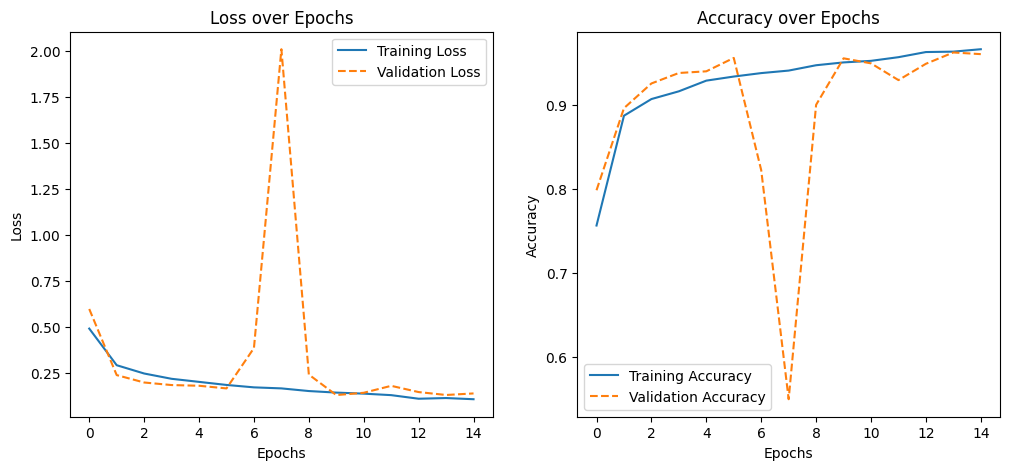

In [10]:
def plot_history(history):
    plt.figure(figsize=(12, 5))

    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='dashed')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss over Epochs')

    # Accuracy Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linestyle='dashed')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy over Epochs')

    plt.show()

# Call the function
plot_history(history)

In [11]:
for i in range(1, 10):
    next_item, label = next(fg())
    prediction = model.predict(next_item)
    print("Prediction:", prediction[0][0], "Label", label)

ValueError: Exception encountered when calling MaxPooling3D.call().

[1mNegative dimension size caused by subtracting 2 from 1 for '{{node sequential_1/max_pooling3d_1/MaxPool3D}} = MaxPool3D[T=DT_FLOAT, data_format="NDHWC", ksize=[1, 1, 2, 2, 1], padding="VALID", strides=[1, 1, 2, 2, 1]](sequential_1/batch_normalization_1/batchnorm/add_1)' with input shapes: [10,100,100,1,32].[0m

Arguments received by MaxPooling3D.call():
  • inputs=tf.Tensor(shape=(10, 100, 100, 1, 32), dtype=float32)

In [11]:
# input_shape=(10, 100, 100, 3)
# input_data="Mouth_RGB"
# def ReadFrames(full_path: str, start, end, isTalking):
#     video = cv2.VideoCapture(full_path)
#     frames = []
#     count = 0
#     while count < input_shape[0] and count <= end:
#         video.set(cv2.CAP_PROP_POS_FRAMES, start+count)
#         ret, frame = video.read()
#         if not ret:
#             break
#             # continue
        

#     frames.append(frame)

    
#     res, frame = video.read()

#     if not res:
#         print("failed to read")
    
   
    # video.release()
# Given a file, start and end frame, produce a len10 array of frames